### Simulating noisy quantum systems with Pauli propagation

In this tutorial we will use the ``pauli-prop`` package to classically simulate the time dynamics of a noisy 9-qubit transverse-field Ising model (TFIM) on a 3x3 square lattice. We will use [PauliLindbladError](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.noise.PauliLindbladError.html) instructions to define a noise channel, $\Lambda$, acting on a set of entangling layers, $\mathcal{U}$. We will then propagate the observable, $O$, backward through the noisy circuit and estimate expectation values for a variety of noise models, as well as the noiseless case.

![Noisy EV](../images/noisy_ev.png)

As the observable is propagated backwards through the circuit, each noise channel, $\Lambda_k$, associated with entangling layer, $\mathcal{U}_k$, damps the Pauli terms in $O$ which anti-commute with its Pauli-Lindblad generators. Specifically, if $G_{k,i}$ is a Pauli generator of $\Lambda_k$ with rate, $\gamma_{k,i}$, then a Pauli term, $P$, in $O$ transforms as: $c_P \mapsto c_P e^{-2\gamma_{k,i}} \quad \text{if } \{P, G_{k,i}\}=0$, where $c_P$ is the coefficient of $P$. Once $O$ has been propagated to the beginning of the circuit, the expectation value with respect to the zero state, $|0\rangle^{\otimes N}$, may be trivially calculated by summing the coefficients in each diagonal term in $O$ (i.e. terms containing $Z$ or $I$ on all qubits).

Workflow:
- Specify the TFIM lattice, and use edge coloring to identify a minimal set of entangling layers
- Generate synthetic noise models, $\Lambda_k$, for each unique entangling layer, $U_k$
  - Create noise models of various scales to study the impact of gate noise on the system
- Create noiseless and noisy quantum circuits for the various depths and noise scales of interest
  - In noisy circuits, ``PauliLindbladError`` instructions are inserted after each entangling layer
- Use Pauli propagation to simulate exact expectation values of the system at various depths
  - For 9 qubits this is done by letting $O$ grow to $4^9$ terms, covering the full Pauli space
- Use Pauli propagation to simulate noisy expectation values
- Observe how increasing gate noise degrades the accuracy of the quantum model

### Generate a 3x3 square lattice and find a 4-coloring on the edges

The vertices in the graph represent qubits, and the edges represent a connection between two qubits. The edge coloring corresponds to unique entangling layers in the quantum circuit such that gates on connections associated with differing colors may not be applied simultaneously.

Identifying a minimal set of unique entangling layers is often important for implementing efficient noise-learning protocols, as the noise for each layer must be learned independently. The more layers one must learn, the more shots they need to take from the QPU. For this demo, we will use the layer information to build up noisy circuits and inject [PauliLindbladError](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.noise.PauliLindbladError.html) instructions from ``qiskit-aer`` after each entangling layer to model QPU gate noise.

In [1]:
import numpy as np
from collections import defaultdict
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.coloring import auto_color_edges

# Define rectangular square-lattice on 20 qubits
num_rows = 3
num_cols = 3
num_qubits = num_rows * num_cols

coupling_map = CouplingMap.from_grid(
    num_rows=num_rows, num_columns=num_cols, bidirectional=False
)

# Find the unique layers
coloring = auto_color_edges(coupling_map.get_edges())
color_to_edge = defaultdict(list)
for edge, color in coloring.items():
    color_to_edge[color].append(edge)

The circuit will have 9 qubits and 4 unique entangling layers.


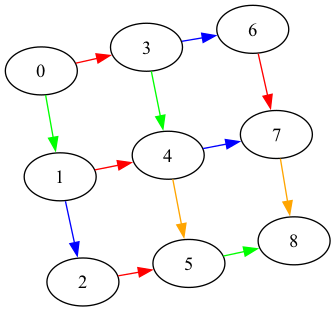

In [2]:
from rustworkx import PyDiGraph
from rustworkx.visualization import graphviz_draw

# Inspect graph coupling and unique entangling layers
print(
    f"The circuit will have {num_qubits} qubits and {len(color_to_edge)} unique entangling layers."
)
sq_lattice = PyDiGraph()
sq_lattice.extend_from_weighted_edge_list(
    [(source, target, color) for ((source, target), color) in coloring.items()]
)


def color_edge_4color(edge):
    color_dict = {0: "red", 1: "green", 2: "blue", 3: "orange"}
    return {"color": color_dict[edge]}


graphviz_draw(sq_lattice, edge_attr_fn=color_edge_4color, method="neato")

### Generate synthetic noise models

Before creating the quantum circuits, we will generate a noise model ([PauliLindbladError](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.noise.PauliLindbladError.html) instance) for each of the entangling layers. We will embed them as instructions in our quantum circuits later. For each layer, we will generate noise channels of varying scales. Specifically, we will generate noise models with [Error Per Layered Gate (EPLG)](https://www.ibm.com/quantum/blog/quantum-metric-layer-fidelity) of approximately ``.0004, .0008, .0012, .0016, and .002``.

In [3]:
from qiskit.quantum_info import pauli_basis, SparsePauliOp
from qiskit_aer.noise import PauliLindbladError

# Pauli-Lindblad noise parameters
seed = 1764
target_EPLGs = [0.0004, .0008, 0.0012, 0.0016, 0.002]


def generate_random_pauli_lindblad_noise(
    edges,
    num_qubits: int | None = None,
    noise_scale: float = 1e-3,
    seed: int | None = None,
) -> PauliLindbladError:
    """Generate random Pauli-Lindblad noise over the full Pauli basis."""
    if num_qubits == None:
        num_qubits = np.max(edges)

    basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
    basis_paulis = SparsePauliOp.from_sparse_list(
        [(pauli.to_label(), edge, 1) for pauli in basis_paulis for edge in edges],
        num_qubits=num_qubits,
    )
    basis_paulis = basis_paulis.simplify()
    basis_paulis = basis_paulis.paulis

    rng = np.random.default_rng(seed=seed)
    rates = rng.random(len(basis_paulis)) * noise_scale

    return PauliLindbladError(generators=basis_paulis, rates=rates)


num_generators = (
    (num_rows * num_cols) + (num_rows - 1) * num_cols + num_rows * (num_cols - 1)
)
noise_scales = [EPLG * (num_rows * num_cols) / num_generators for EPLG in target_EPLGs]
noise_models_per_EPLG = [
    [
        generate_random_pauli_lindblad_noise(
            coupling_map.get_edges(),
            num_qubits=num_qubits,
            noise_scale=noise_scale,
            seed=seed,
        )
        for _ in range(len(color_to_edge))
    ]
    for noise_scale in noise_scales
]

### Create the quantum circuits

For this demo, we will simulate the time dynamics of a transverse-field Ising model (TFIM) for increasing numbers of Trotter steps (1-7 steps). For each of the 7 circuit depths, we will simulate the effect of gate noise, given noise models of varying scales (``EPLGs = .0001, .0002, .0005, .001, .002``). The noise is injected as a ``QuantumCircuit`` instruction using the [PauliLindbladError](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.noise.PauliLindbladError.html) class from Qiskit Aer. The Hamiltonian considered is:

$H = -J\sum\limits_{\langle i,j \rangle} Z_iZ_j + h\sum\limits_iX_i$

where $J>0$ describes the coupling of nearest-neighbor spins, $i<j$, and $h$ is the global transverse field.

Here we implement the time-evolved Hamiltonian across various time and noise scales. We create 42 total circuits -- 7 noiseless circuits varying in Trotter depth and 35 noisy circuits for the 7 Trotter depths across 5 noise scales. Given a connectivity graph, the model is parametrized by a few variables:
- ``num_steps``: The number of Trotter steps
- ``J``: Coupling strength of connected sites
- ``h``: Strength of external magnetic field
- ``dt``: Change in time across a Trotter step
- ``initial_state_angle``: An initial excitation, $R_y(\theta)$, to be applied uniformly to all qubits

In [4]:
from typing import Any
from qiskit import QuantumCircuit

# Ising model parameters
num_steps = 7
J = -1.0
dt = 0.25 / abs(J)
h = 2.0 * abs(J)
initial_state_angle = np.pi / 18.0
rx_angle = 2.0 * h * dt
rz_angle = 2.0 * J * dt


def generate_ising_circuit(
    num_qubits: int,
    num_steps: int,
    rx_angle: float,
    rz_angle: float,
    coloring: dict[Any, list[tuple[int, int]]],
    layer_noise_models: list[PauliLindbladError] | None = None,
    initial_state_angle: float | None = None,
) -> QuantumCircuit:
    """Generate a quantum circuit implementing a transverse-field Ising model"""
    qc = QuantumCircuit(num_qubits)
    if initial_state_angle:
        qc.ry(initial_state_angle, range(num_qubits))
    qc.rx(rx_angle / 2, range(num_qubits))
    for i in range(num_steps):
        for i, layer in enumerate(coloring):
            edges = coloring[layer]
            for edge in edges:
                qc.cx(*edge)
            if layer_noise_models:
                qc.append(layer_noise_models[i], qargs=range(num_qubits))
            for edge in edges:
                qc.rz(rz_angle, edge[1])
            for edge in edges:
                qc.cx(*edge)
            if layer_noise_models:
                qc.append(layer_noise_models[i], qargs=range(num_qubits))
        if i == num_steps - 1:
            qc.rx(rx_angle / 2, range(num_qubits))
        else:
            qc.rx(rx_angle, range(num_qubits))
    return qc


# Create the noiseless and noisy circuits
noiseless_circs = []
noisy_circs = []
for steps in range(num_steps):
    noiseless_circs.append(
        generate_ising_circuit(
            num_qubits,
            steps,
            rx_angle,
            rz_angle,
            color_to_edge,
            initial_state_angle=initial_state_angle,
        )
    )
    noisy_circs_per_step = []
    for i, noise_models in enumerate(noise_models_per_EPLG):
        noisy_circs_per_step.append(
            generate_ising_circuit(
                num_qubits,
                steps,
                rx_angle,
                rz_angle,
                color_to_edge,
                layer_noise_models=noise_models,
                initial_state_angle=initial_state_angle,
            )
        )
    noisy_circs.append(noisy_circs_per_step)
print(
    f"{num_steps} noiseless and {num_steps * len(target_EPLGs)} noisy Trotter circuits generated\n  - {num_steps} different depths across {len(target_EPLGs)} different noise models"
)

7 noiseless and 35 noisy Trotter circuits generated
  - 7 different depths across 5 different noise models


### Specify observable and run simulations

For this demo, we will simulate expectation values of the average two-site correlator:

$\langle O \rangle = \langle Z_{tot}^2(s) \rangle = \frac{1}{N^2}\sum \langle \Psi(\theta)|(\mathscr{U}^{\dagger})^sZ_jZ_k(\mathscr{U})^s|\Psi(\theta) \rangle$

where $\Psi(\theta)$ corresponds to a uniform $R_y(\theta)$ rotation on all qubits, $\mathscr{U}^s$ describes $s$ Trotter layers, and $(j,k)$ index all pairs of vertices on the lattice.

Finally, we will use ``pauli_prop`` to simulate observable expectation values for each of the circuits. For this 9-qubit demo, we will perform all simulations **exactly**. **No Pauli propagation trunction will be performed; therefore, the differences in expectation values across the different noise models can be entirely attributed to the gate error**. The simulation process is handled in 4 steps:
- Evolve the Clifford gates in the circuit to the front of the circuit using ``pauli_prop.evolve_through_cliffords``
- Propagate the observable through the non-Clifford part of the circuit using ``pauli_prop.propagate_through_circuit``
  - We perform exact simulations by allowing the observable to grow to the size of the full Pauli space, ``4**9``.
- Propagate the evolved observable through the Clifford part of the circuit using Qiskit's ``SparsePauliOp.evolve``
- Estimate the expectation value with respect to the zero state, $|0\rangle^{\otimes N}$, by summing the coefficients in each diagonal term in $O$ (i.e. terms containing $Z$ or $I$ on all qubits).

In [5]:
import time
from qiskit.quantum_info import Pauli
from pauli_prop import evolve_through_cliffords, propagate_through_circuit

# Average ZZ-correlator observable
id_pauli = Pauli("I" * num_qubits)
observable = 2 * SparsePauliOp(
    [
        id_pauli.dot(Pauli("ZZ"), [i, j])
        for i in range(num_qubits)
        for j in range(i + 1, num_qubits)
    ]
)
observable /= num_qubits**2

# Pauli propagation parameters
max_terms = 4**num_qubits  # Exact propagation
atol = 1e-12

# Run simulations
exact_evs = []
noisy_evs = [[] for _ in range(len(target_EPLGs))]
st = time.perf_counter()
for i, noiseless_circ in enumerate(noiseless_circs):
    cliff, non_cliff = evolve_through_cliffords(noiseless_circ)
    evolved_obs = propagate_through_circuit(
        observable, non_cliff, max_terms=max_terms, atol=atol, frame="h"
    )[0]
    evolved_obs.paulis = evolved_obs.paulis.evolve(cliff, frame="h")
    exact_evs.append(float(evolved_obs.coeffs[~evolved_obs.paulis.x.any(axis=1)].sum()))
    for j in range(len(target_EPLGs)):
        noisy_circ = noisy_circs[i][j]
        cliff, non_cliff = evolve_through_cliffords(noisy_circ)
        evolved_obs = propagate_through_circuit(
            observable, non_cliff, max_terms=max_terms, atol=1e-12, frame="h"
        )[0]
        evolved_obs.paulis = evolved_obs.paulis.evolve(cliff, frame="h")
        noisy_evs[j].append(
            float(evolved_obs.coeffs[~evolved_obs.paulis.x.any(axis=1)].sum())
        )
print(
    f"Ran {len(noiseless_circs)} noiseless and {len(target_EPLGs) * num_steps} noisy simulations in {int(time.perf_counter()-st)}s."
)

Ran 7 noiseless and 35 noisy simulations in 86s.


### Observe effect of gate error on the model

Remember, since this is a 9-qubit experiment, the Pauli propagation routine is exact, and all of the error in the noise plots can be attributed to gate error.

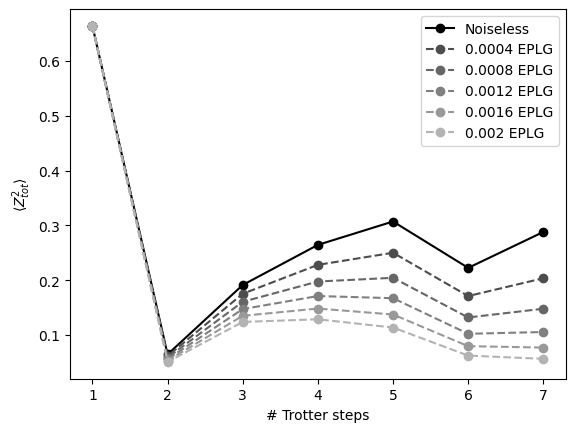

In [6]:
import matplotlib.pyplot as plt

xs = range(1, num_steps + 1)
plt.plot(xs, exact_evs, label="Noiseless", color="black", marker="o")
colors = [".3", ".4", ".5", ".6", ".7"]
for i, evs in enumerate(noisy_evs):
    plt.plot(
        xs,
        evs,
        label=f"{target_EPLGs[i]} EPLG",
        linestyle="--",
        color=colors[i],
        marker="o",
    )
plt.xlabel("# Trotter steps")
plt.ylabel(r"$\langle Z_{tot}^2 \rangle$")
plt.legend()
plt.show()